# **MIT 6.5940 EfficientML.ai Lab 2: Quantization**

This colab notebook provides code and a framework for Lab 2 quantization. You can work out your solutions here.

## Goals

In this assignment, you will practice quantizing a classical neural network model to reduce both model size and latency. The goals of this assignment are as follows:
- Understand the basic concept of **quantization**
- Implement and apply **k-means quantization**
- Implement and apply **quantization-aware training** for k-means quantization
- Implement and apply **linear quantization**
- Implement and apply **integer-only inference** for linear quantization
- Get a basic understanding of performance improvement (such as speedup) from quantization
- Understand the differences and tradeoffs between these quantization approaches

## Contents

There are **2** main sections: **K-Means Quantization** and **Linear Quantization**.

There are ***10*** questions in total:

- For *K-Means Quantization*, there are *3* questions (Question 1-3).
- For *Linear Quantization*, there are *6* questions (Question 4-9).
- Question 10 compares k-means quantization and linear quantization.

## Setup

First, install the required packages and download the datasets and pretrained model. Here we use CIFAR10 dataset and VGG network which is the same as what we used in the Lab 0 tutorial.

In [7]:
print('Installing torchprofile...')
!pip install torchprofile 1>/dev/null
print('Installing fast-pytorch-kmeans...')
! pip install fast-pytorch-kmeans 1>/dev/null
print('All required packages have been successfully installed!')

Installing torchprofile...
Installing fast-pytorch-kmeans...
All required packages have been successfully installed!


In [8]:
import copy
import math
import random
from collections import OrderedDict, defaultdict

from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader
from torchprofile import profile_macs
from torchvision.datasets import *
from torchvision.transforms import *

assert torch.cuda.is_available(), \
"The current runtime does not have CUDA support." \
"Please go to menu bar (Runtime - Change runtime type) and select GPU"

In [9]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [10]:
def download_url(url, model_dir='.', overwrite=False):
    import os, sys
    from urllib.request import urlretrieve
    target_dir = url.split('/')[-1]
    model_dir = os.path.expanduser(model_dir)
    try:
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)
        model_dir = os.path.join(model_dir, target_dir)
        cached_file = model_dir
        if not os.path.exists(cached_file) or overwrite:
            sys.stderr.write('Downloading: "{}" to {}\n'.format(url, cached_file))
            urlretrieve(url, cached_file)
        return cached_file
    except Exception as e:
        # remove lock file so download can be executed next time.
        os.remove(os.path.join(model_dir, 'download.lock'))
        sys.stderr.write('Failed to download from url %s' % url + '\n' + str(e) + '\n')
        return None

In [23]:
class VGG(nn.Module):
  ARCH = [
      64,
      128,
      'M',
      256,
      256,
      'M',
      512,
      512,
      'M',
      512,
      512,
      'M'
  ]

  def __init__(self) -> None:
    super().__init__()

    layers = []
    counts = defaultdict(int)

    def add(name: str, layer: nn.Module) -> None:
      layers.append((f"{name}{counts[name]}", layer))
      counts[name] += 1

    in_channels = 3
    for x in self.ARCH:
      if x != 'M':
        # conv-bn-relu
        add("conv", nn.Conv2d(in_channels, x, 3, padding=1, bias=False))
        add("bn", nn.BatchNorm2d(x))
        add("relu", nn.ReLU(True))
        in_channels = x
      else:
        # maxpool
        add("pool", nn.MaxPool2d(2))

    add("avgpool", nn.AvgPool2d(2))
    self.backbone = nn.Sequential(OrderedDict(layers))
    self.classifier = nn.Linear(512, 10)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    # backbone: [N, 3, 32, 32] => [N, 512, 2, 2]
    x = self.backbone(x)

    # avgpool: [N, 512, 2, 2] => [N. 512]
    # x = x.mean([2, 3])
    x = x.view(x.shape[0], -1)

    # classifier: [N, 512] => [N, 10]
    x = self.classifier(x)

    return x

In [12]:
def train(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: Optimizer,
    scheduler: LambdaLR,
    callbacks = None
) -> None:

  model.train()

  for inputs, targets in tqdm(dataloader, desc='train', leave=False):
    # Move to data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Reset the gradients (from the last iteration)
    optimizer.zero_grad()

    # Forward inference
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward propagation
    loss.backward()

    # Update optimizer and LR scheduler
    optimizer.step()
    scheduler.step()

    if callbacks is not None:
      for callback in callbacks:
        callback()

In [13]:
@torch.inference_mode()
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    extra_preprocess = None
) -> float:

  model.eval()

  num_samples = 0
  num_correct = 0

  for inputs, targets in tqdm(dataloader, desc="eval", leave=False):
    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    if extra_preprocess is not None:
      for preprocess in extra_preprocess:
        inputs = preprocess(inputs)

    targets = targets.cuda()

    # Inference
    outputs = model(inputs)

    # Convert logits to class indices
    outputs = outputs.argmax(dim=1)

    # Update metrics
    num_samples += targets.size(0)
    num_correct += (outputs == targets).sum()

  return (num_correct / num_samples * 100).item()

Helper Functions (Flops, Model Size calculation, etc.)

In [6]:
def get_model_flops(model, inputs):
  num_macs = profile_macs(model, inputs)
  return num_macs

In [2]:
def get_model_size(model: nn.Module, data_width=32):
  """
  calculate the model size in bits
  :param data_width: #bits per element
  """
  num_elements = 0
  for param in model.parameters():
    num_elements += param.numel()
  return num_elements * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

Define misc functions for verification.

In [14]:
def test_k_means_quantize(
    test_tensor=torch.tensor(
        [
            [-0.3747,  0.0874,  0.3200, -0.4868,  0.4404],
            [-0.0402,  0.2322, -0.2024, -0.4986,  0.1814],
            [ 0.3102, -0.3942, -0.2030,  0.0883, -0.4741],
            [-0.1592, -0.0777, -0.3946, -0.2128,  0.2675],
            [ 0.0611, -0.1933, -0.4350,  0.2928, -0.1087]
        ]
    ),
    bitwidth=2
):

    def plot_matrix(
        tensor, ax, title, cmap=ListedColormap(['white'])
    ):
        ax.imshow(tensor.cpu().numpy(), vmin=-0.5, vmax=0.5, cmap=cmap)
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[1]):
            for j in range(tensor.shape[0]):
                text = ax.text(j, i, f'{tensor[i, j].item():.2f}',
                                ha="center", va="center", color="k")

    fig, axes = plt.subplots(1, 2, figsize=(8, 12))
    ax_left, ax_right = axes.ravel()

    print(test_tensor)
    plot_matrix(test_tensor, ax_left, 'original tensor')

    num_unique_values_before_quantization = test_tensor.unique().numel()
    k_means_quantize(test_tensor, bitwidth=bitwidth)
    num_unique_values_after_quantization = test_tensor.unique().numel()

    print('* Test k_means_quantize()')
    print(f'    target bitwidth: {bitwidth} bits')
    print(f'        num unique values before k-means quantization: {num_unique_values_before_quantization}')
    print(f'        num unique values after  k-means quantization: {num_unique_values_after_quantization}')
    assert num_unique_values_after_quantization == min((1 << bitwidth), num_unique_values_before_quantization)
    print('* Test passed.')

    plot_matrix(test_tensor, ax_right, f'{bitwidth}-bit k-means quantized tensor', cmap='tab20c')
    fig.tight_layout()
    plt.show()

In [ ]:
def test_linear_quantize(
    test_tensor=torch.tensor(
        [
            [ 0.0523,  0.6364, -0.0968, -0.0020,  0.1940],
            [ 0.7500,  0.5507,  0.6188, -0.1734,  0.4677],
            [-0.0669,  0.3836,  0.4297,  0.6267, -0.0695],
            [ 0.1536, -0.0038,  0.6075,  0.6817,  0.0601],
            [ 0.6446, -0.2500,  0.5376, -0.2226,  0.2333]
        ]
    ),
    quantized_test_tensor=torch.tensor(
        [
            [-1,  1, -1, -1,  0],
            [ 1,  1,  1, -2,  0],
            [-1,  0,  0,  1, -1],
            [-1, -1,  1,  1, -1],
            [ 1, -2,  1, -2,  0]
        ],
        dtype=torch.int8
    ),
    real_min=-0.25,
    real_max=0.75,
    bitwidth=2,
    scale=1/3,
    zero_point=-1
):
    def plot_matrix(tensor, ax, title, vmin=0, vmax=1, cmap=ListedColormap(['white'])):
        ax.imshow(tensor.cpu().numpy(), vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[0]):
            for j in range(tensor.shape[1]):
                datum = tensor[i, j].item()
                if isinstance(datum, float):
                    text = ax.text(j, i, f'{datum:.2f}', ha="center", va="center", color="k")
                else:
                    text = ax.text(j, i, f'{datum}', ha="center", va="center", color="k")
    
    quantized_min, quantized_max = get_quantized_range(bitwidth)

    fig, axes = plt.subplots(1,3, figsize=(10, 32))

    plot_matrix(test_tensor, axes[0], 'original tensor', vmin=real_min, vmax=real_max)

    _quantized_test_tensor = linear_quantize(
        test_tensor,
        bitwidth=bitwidth,
        scale=scale,
        zero_point=zero_point
    )

    _reconstructed_test_tensor = scale * (_quantized_test_tensor.float() - zero_point)

    print('* Test linear_quantize()')
    print(f'    target bitwidth: {bitwidth} bits')
    print(f'        scale: {scale}')
    print(f'        zero point: {zero_point}')

    assert _quantized_test_tensor.equal(quantized_test_tensor)

    print('* Test passed.')

    plot_matrix(_quantized_test_tensor, axes[1], f'2-bit linear quantized tensor',
                vmin=quantized_min, vmax=quantized_max, cmap='tab20c')
    plot_matrix(_reconstructed_test_tensor, axes[2], f'reconstructed tensor',
                vmin=real_min, vmax=real_max, cmap='tab20c')
    fig.tight_layout()
    plt.show()

Load Pretrained Model

In [24]:
checkpoint_url = "https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth"

checkpoint = torch.load(download_url(checkpoint_url), map_location="cpu")

model = VGG().cuda()

print(f"=> loading checkpoint '{checkpoint_url}'")

model.load_state_dict(checkpoint['state_dict'])

recover_model = lambda : model.load_state_dict(checkpoint['state_dict'])

=> loading checkpoint 'https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth'


In [26]:
image_size = 32
transforms = {
    "train": Compose([
        RandomCrop(image_size, padding=4),
        RandomHorizontalFlip(),
        ToTensor(),
    ]),
    "test": ToTensor(),
}

dataset = {}
for split in ["train", "test"]:
    dataset[split] = CIFAR10(
        root="data/cifar10",
        train=(split == "train"),
        download=True,
        transform=transforms[split],
    )

dataloader = {}
for split in ['train', 'test']:
    dataloader[split] = DataLoader(
        dataset[split],
        batch_size=512,
        shuffle=(split == 'train'),
        num_workers=0,
        pin_memory=True
    )

100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s] 


# Let's First Evaluate the Accuracy and Model Size of the FP32 Model

In [30]:
fp32_model_accuracy = evaluate(model, dataloader['test'])
fp32_model_size = get_model_size(model)

print(f"fp32 model has accuracy={fp32_model_accuracy:.2f}%")
print(f"fp32 model has size={fp32_model_size/MiB:.2f} MiB")

eval:   0%|          | 0/20 [00:00<?, ?it/s]

fp32 model has accuracy=92.76%
fp32 model has size=35.20 MiB


## K-Means Quantization

Network quantization compresses the network by reducing the bits per weight required to represent the deep network. The quantized network can have a faster inference speed with hardware support.

In this section, we will explore the K-means quantization for neural networks as in Deep Compression: Compressing Deep Neural Networks With Pruning, Trained Quantization And Huffman Coding.

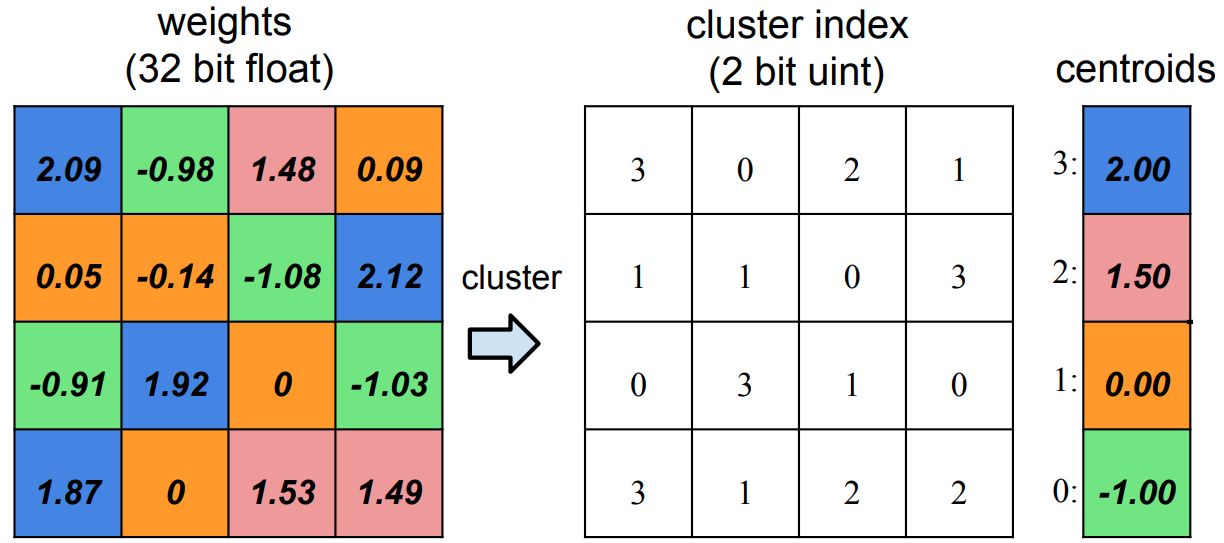

A $n$-bit k-means quantization will divide synapses into $2^n$ clusters, and synapses in the same cluster will share the same weight value.

Therefore, k-means quantization will create a codebook, inlcuding
*   `centroids`: $2^n$ fp32 cluster centers.
*   `labels`: a $n$-bit integer tensor with the same #elements of the original fp32 weights tensor. Each integer indicates which cluster it belongs to.

During the inference, a fp32 tensor is generated based on the codebook for inference:

> ***quantized_weight* = *codebook.centroids*\[*codebook.labels*\].view_as(weight)**

In [4]:
from collections import namedtuple

Codebook = namedtuple('Codebook', ['centroids', 'label'])

## Question 1 (10 pts)

Please complete the following K-Means quantization function.

In [15]:
from fast_pytorch_kmeans import KMeans

def k_means_quantize(fp32_tensor: torch.Tensor, bitwidth=4, codebook=None):
    """
    quantize tensor using k-means clustering
    :param fp32_tensor
    :param bitwidth: [int] quantization bit width, default=4
    :param codebook: [Codebook] (the cluster centroids, the cluster label tensor)
    :return:
        [Codebook = (centroids, labels)]
            centroids: [torch.(cuda.)FloatTensor] the cluster centroids
            labels: [torch.(cuda.)LongTensor] cluster label tensor
    """
    if codebook is None:
        ############### YOUR CODE STARTS HERE ###############
        # get number of clusters based on the quantization precision
        # hint: one line of code
        n_clusters = 2 ** bitwidth
        ############### YOUR CODE ENDS HERE #################
        # use k-means to get the quantization centroids
        kmeans = KMeans(
            n_clusters=n_clusters,
            mode='euclidean',
            verbose=0
        )
        labels = kmeans.fit_predict(fp32_tensor.view(-1, 1)).to(torch.long)
        centroids = kmeans.centroids.to(torch.float).view(-1)
        codebook = Codebook(centroids, labels)

    ############### YOUR CODE STARTS HERE ###############
    # decode the codebook into k-means quantized tensor for inference
    # hint: one line of code
    quantized_tensor = codebook.centroids[codebook.label].view(-1)
    ############### YOUR CODE ENDS HERE #################
    fp32_tensor.set_(quantized_tensor.view_as(fp32_tensor))
    return codebook

Let's verify the functionality of defined k-means quantization by applying the function above on a dummy tensor.

tensor([[-0.3747,  0.0874,  0.3200, -0.4868,  0.4404],
        [-0.0402,  0.2322, -0.2024, -0.4986,  0.1814],
        [ 0.3102, -0.3942, -0.2030,  0.0883, -0.4741],
        [-0.1592, -0.0777, -0.3946, -0.2128,  0.2675],
        [ 0.0611, -0.1933, -0.4350,  0.2928, -0.1087]])
* Test k_means_quantize()
    target bitwidth: 2 bits
        num unique values before k-means quantization: 25
        num unique values after  k-means quantization: 4
* Test passed.


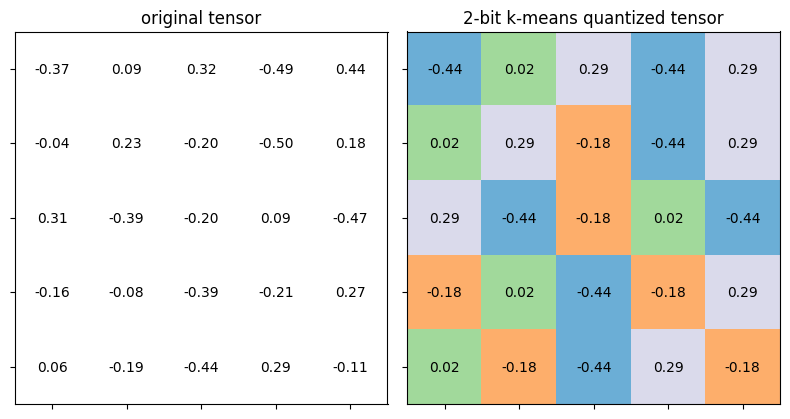

In [16]:
test_k_means_quantize()

## Question 2 (10 pts)

The last code cell performs 2-bit k-means quantization and plots the tensor before and after the quantization. Each cluster is rendered with a unique color. There are 4 unique colors rendered in the quantized tensor.

Given this observation, please answer the following questions.

### Question 2.1 (5 pts)

If 4-bit k-means quantization is performed, how many unique colors will be rendered in the quantized tensor?

**Your Answer:**

Absolutely *16* colors

### Question 2.2 (5 pts)

If *n*-bit k-means quantization is performed, how many unique colors will be rendered in the quantized tensor?

**Your Answer:**

$2^n$ colors

## K-Means Quantization on Whole Model

Similar to what we did in lab 1, we now wrap the k-means quantization function into a class for quantizing the whole model. In class `KMeansQuantizer`, we have to keep a record of the codebooks (i.e., `centroids` and `labels`) so that we could apply or update the codebooks whenever the model weights change.

In [17]:
from torch.nn import parameter

In [18]:
class KMeansQuantizer:
    def __init__(self, model: nn.Module, bitwidth=4):
        self.codebook = KMeansQuantizer.quantize(model, bitwidth)

    @torch.no_grad()
    def apply(self, model, update_centroids):
        for name, param in model.named_parameters():
            if name in self.codebook:
                if update_centroids:
                    update_codebook(param, codebook=self.codebook[name])
                self.codebook[name] = k_means_quantize(param, codebook=self.codebook[name])


    @staticmethod
    @torch.no_grad()
    def quantize(model: nn.Module, bitwidth=4):
        codebook = dict()
        if isinstance(bitwidth, dict):
            for name, param in model.named_parameters():
                if name in bitwidth:
                    codebook[name] = k_means_quantize(param, bitwidth=bitwidth[name])
        else:
            for name, param in model.named_parameters():
                if param.dim() > 1:
                    codebook[name] = k_means_quantize(param, bitwidth=bitwidth)
        return codebook

Now let's quantize model into 8 bits, 4 bits and 2 bits using K-Means Quantization. *Note that we ignore the storage for codebooks when calculating the model size.*

In [27]:
print('Note that the storage for codebooks is ignored when calculating the model size.')
quantizers = dict()
for bitwidth in [8, 4, 2]:
    recover_model()
    print(f'k-means quantizing model into {bitwidth} bits')
    quantizer = KMeansQuantizer(model, bitwidth)
    quantized_model_size = get_model_size(model, bitwidth)
    print(f"    {bitwidth}-bit k-means quantized model has size={quantized_model_size/MiB:.2f} MiB")
    quantized_model_accuracy = evaluate(model, dataloader['test'])
    print(f"    {bitwidth}-bit k-means quantized model has accuracy={quantized_model_accuracy:.2f}%")
    quantizers[bitwidth] = quantizer

Note that the storage for codebooks is ignored when calculating the model size.
k-means quantizing model into 8 bits
    8-bit k-means quantized model has size=8.80 MiB


eval:   0%|          | 0/20 [00:00<?, ?it/s]

    8-bit k-means quantized model has accuracy=92.76%
k-means quantizing model into 4 bits
    4-bit k-means quantized model has size=4.40 MiB


eval:   0%|          | 0/20 [00:00<?, ?it/s]

    4-bit k-means quantized model has accuracy=79.07%
k-means quantizing model into 2 bits
    2-bit k-means quantized model has size=2.20 MiB


eval:   0%|          | 0/20 [00:00<?, ?it/s]

    2-bit k-means quantized model has accuracy=10.00%


## Trained K-Means Quantization

As we can see from the results of last cell, the accuracy significantly drops when quantizing the model into lower bits. Therefore, we have to perform quantization-aware training to recover the accuracy.

During the k-means quantization-aware training, the centroids are also updated, which is proposed in [Deep Compression: Compressing Deep Neural Networks With Pruning, Trained Quantization
And Huffman Coding](https://arxiv.org/pdf/1510.00149.pdf).

The gradient for the centroids is calculated as,

> $\frac{\partial \mathcal{L} }{\partial C_k} = \sum_{j} \frac{\partial \mathcal{L} }{\partial W_{j}} \frac{\partial W_{j} }{\partial C_k} = \sum_{j} \frac{\partial \mathcal{L} }{\partial W_{j}} \mathbf{1}(I_{j}=k)$

where $\mathcal{L}$ is the loss, $C_k$ is *k*-th centroid, $I_{j}$ is the label for weight $W_{j}$. $\mathbf{1}()$ is the indicator function, and $\mathbf{1}(I_{j}=k)$ means $1\;\mathrm{if}\;I_{j}=k\;\mathrm{else}\;0$, *i.e.*, $I_{j}==k$.

Here in the lab, **for simplicity**, we directly update the centroids according to the latest weights:

> $C_k = \frac{\sum_{j}W_{j}\mathbf{1}(I_{j}=k)}{\sum_{j}\mathbf{1}(I_{j}=k)}$

### Question 3 (10 pts)

Please complete the following codebook update function.

**Hint**:

The above equation for updating centroids is indeed using the `mean` of weights in the same cluster to be the updated centroid value.

In [28]:
def update_codebook(fp32_tensor: torch.Tensor, codebook: Codebook):
    """
    update the centroids in the codebook using updated fp32_tensor
    :param fp32_tensor: [torch.(cuda.)Tensor]
    :param codebook: [Codebook] (the cluster centroids, the cluster label tensor)
    """
    n_clusters = codebook.centroids.numel()
    fp32_tensor = fp32_tensor.view(-1)
    for k in range(n_clusters):
        ############### YOUR CODE STARTS HERE ###############
        # hint: one line of code
        codebook.centroids[k] = fp32_tensor[codebook.label == k].mean()
        ############### YOUR CODE ENDS HERE #################

Now let's run the following code cell to finetune the k-means quantized model to recover the accuracy. We will stop finetuning if accuracy drop is less than 0.5.

In [31]:
accuracy_drop_threshold = 0.5
quantizers_before_finetune = copy.deepcopy(quantizers)
quantizers_after_finetune = quantizers

for bitwidth in [8, 4, 2]:
    recover_model()

    quantizer = quantizers[bitwidth]
    print(f'k-means quantizing model into {bitwidth} bits')

    quantizer.apply(model, update_centroids=False)
    quantized_model_size = get_model_size(model, bitwidth)

    print(f"    {bitwidth}-bit k-means quantized model has size={quantized_model_size/MiB:.2f} MiB")

    quantized_model_accuracy = evaluate(model, dataloader['test'])

    print(f"    {bitwidth}-bit k-means quantized model has accuracy={quantized_model_accuracy:.2f}% before quantization-aware training ")

    accuracy_drop = fp32_model_accuracy - quantized_model_accuracy

    if accuracy_drop > accuracy_drop_threshold:
        print(f"        Quantization-aware training due to accuracy drop={accuracy_drop:.2f}% is larger than threshold={accuracy_drop_threshold:.2f}%")
        num_finetune_epochs = 5
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=0.01,
            momentum=0.9
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            num_finetune_epochs
        )
        criterion = nn.CrossEntropyLoss()
        best_accuracy = 0
        epoch = num_finetune_epochs

        while accuracy_drop > accuracy_drop_threshold and epoch > 0:
            train(
                model,
                dataloader['train'],
                criterion,
                optimizer,
                scheduler,
                callbacks=[
                    lambda: quantizer.apply(model, update_centroids=True)
                ]
            )
            model_accuracy = evaluate(model, dataloader['test'])
            is_best = model_accuracy > best_accuracy
            best_accuracy = max(model_accuracy, best_accuracy)

            print(f'        Epoch {num_finetune_epochs-epoch} Accuracy {model_accuracy:.2f}% / Best Accuracy: {best_accuracy:.2f}%')

            accuracy_drop = fp32_model_accuracy - best_accuracy
            epoch -= 1
    
    else:
        print(f"        No need for quantization-aware training since accuracy drop={accuracy_drop:.2f}% is smaller than threshold={accuracy_drop_threshold:.2f}%")

k-means quantizing model into 8 bits
    8-bit k-means quantized model has size=8.80 MiB


eval:   0%|          | 0/20 [00:00<?, ?it/s]

    8-bit k-means quantized model has accuracy=92.76% before quantization-aware training 
        No need for quantization-aware training since accuracy drop=0.00% is smaller than threshold=0.50%
k-means quantizing model into 4 bits
    4-bit k-means quantized model has size=4.40 MiB


eval:   0%|          | 0/20 [00:00<?, ?it/s]

    4-bit k-means quantized model has accuracy=79.07% before quantization-aware training 
        Quantization-aware training due to accuracy drop=13.69% is larger than threshold=0.50%


...

eval:   0%|          | 0/20 [00:00<?, ?it/s]

        Epoch 3 Accuracy 91.08% / Best Accuracy: 91.08%


train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/20 [00:00<?, ?it/s]

        Epoch 4 Accuracy 91.16% / Best Accuracy: 91.16%


# Linear Quantization

In this section, we will implement and perform linear quantization.

Linear quantization directly rounds the floating-point value into the nearest quantized integer after range truncation and scaling.

[Linear quantization](https://arxiv.org/pdf/1712.05877.pdf) can be represented as

$r = S(q-Z)$

where $r$ is a floating point real number, $q$ is a *n*-bit integer, $Z$ is a *n*-bit integer, and $S$ is a floating point real number. $Z$ is quantization zero point and $S$ is quantization scaling factor. Both constant $Z$ and $S$ are quantization parameters.

## *n*-bit Integer

A *n*-bit signed integer is usually represented in [two's complement](https://en.wikipedia.org/wiki/Two%27s_complement) notation.

A *n*-bit signed integer can enode integers in the range $[-2^{n-1}, 2^{n-1}-1]$. For example, a 8-bit integer falls in the range [-128, 127].

In [ ]:
def get_quantized_range(bitwidth):
    # 1      = 0001
    # 1 << 3 = 1000
    # => Vì mỗi lần dịch trái 1 bit ≈ nhân 2.
    quantized_max = (1 << (bitwidth - 1)) - 1
    quantized_min = -(1 << (bitwidth - 1))
    return quantized_min, quantized_max

## **Question 4** (10 pts)

Please complete the following linear quantization function.

**Hint**:
*   From $r=S(q-Z)$, we have $q = r/S + Z$.
*   Both $r$ and $S$ are floating numbers, and thus we cannot directly add integer $Z$ to $r/S$. Therefore $q = \mathrm{int}(\mathrm{round}(r/S)) + Z$.
*   To convert [`torch.FloatTensor`](https://pytorch.org/docs/stable/tensors.html) to [`torch.IntTensor`](https://pytorch.org/docs/stable/tensors.html), we could use [`torch.round()`](https://pytorch.org/docs/stable/generated/torch.round.html#torch.round), [`torch.Tensor.round()`](https://pytorch.org/docs/stable/generated/torch.Tensor.round.html#torch.Tensor.round), [`torch.Tensor.round_()`](https://pytorch.org/docs/stable/generated/torch.Tensor.round_) to first convert all values to floating integer, and then use [`torch.Tensor.to(torch.int8)`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html#torch.Tensor.to) to convert the data type from [`torch.float`](https://pytorch.org/docs/stable/tensors.html) to [`torch.int8`](https://pytorch.org/docs/stable/tensors.html).



In [ ]:
def linear_quantize(
        fp_tensor,
        bitwidth,
        scale,
        zero_point,
        dtype=torch.int8
) -> torch.Tensor:
    """
    linear quantization for single fp_tensor
      from
        fp_tensor = (quantized_tensor - zero_point) * scale
      we have,
        quantized_tensor = int(round(fp_tensor / scale)) + zero_point
    :param tensor: [torch.(cuda.)FloatTensor] floating tensor to be quantized
    :param bitwidth: [int] quantization bit width
    :param scale: [torch.(cuda.)FloatTensor] scaling factor
    :param zero_point: [torch.(cuda.)IntTensor] the desired centroid of tensor values
    :return:
        [torch.(cuda.)FloatTensor] quantized tensor whose values are integers
    """
    assert(fp_tensor.dtype == torch.float)
    assert(isinstance(scale, float) or (scale.dtype == torch.float and scale.dim() == fp_tensor.dim()))
    assert(isinstance(zero_point, int) or (zero_point.dtype == dtype and zero_point.dim() == fp_tensor.dim()))

    ############### YOUR CODE STARTS HERE ###############
    # Step 1: scale the fp_tensor
    scaled_tensor = 0
    # Step 2: round the floating value to integer value
    rounded_tensor = 0
    ############### YOUR CODE ENDS HERE #################

    rounded_tensor = rounded_tensor.to(dtype)

    ############### YOUR CODE STARTS HERE ###############
    # Step 3: shift the rounded_tensor to make zero_point 0
    shifted_tensor = 0
    ############### YOUR CODE ENDS HERE #################

    # Step 4: clamp the shifted_tensor to lie in bitwidth-bit range
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    quantized_tensor = shifted_tensor.clamp_(quantized_min, quantized_max)
    return quantized_tensor

Let's verify the functionality of defined linear quantization by applying the function above on a dummy tensor.

In [ ]:
test_linear_quantize()

## Question 5 (15 pts)

Now we have to determine the scaling factor $S$ and zero point $Z$ for linear quantization.

Recall that [linear quantization](https://arxiv.org/pdf/1712.05877.pdf) can be represented as

$r = S(q-Z)$

### Scale

Linear quantization projects the floating point range [*fp_min*, *fp_max*] to the quantized range [*quantized_min*, *quantized_max*]. That is to say,

> $r_{\mathrm{max}} = S(q_{\mathrm{max}}-Z)$
>
> $r_{\mathrm{min}} = S(q_{\mathrm{min}}-Z)$

Substracting these two equations, we have,


#### Question 5.1 (3 pts)

Please select the correct answer and delete the wrong answers in the next text cell.

> $S=r_{\mathrm{max}} / q_{\mathrm{max}}$

> $S=(r_{\mathrm{max}} + r_{\mathrm{min}}) / (q_{\mathrm{max}} + q_{\mathrm{min}})$

> $S=(r_{\mathrm{max}} - r_{\mathrm{min}}) / (q_{\mathrm{max}} - q_{\mathrm{min}})$

> $S=r_{\mathrm{max}} / q_{\mathrm{max}} - r_{\mathrm{min}} / q_{\mathrm{min}}$


There are different approaches to determine the $r_{\mathrm{min}}$ and  $r_{\mathrm{max}}$ of a floating point tensor `fp_tensor`.

*   The most common method is directly using the minimum and maximum value of `fp_tensor`.
*   Another widely used method is minimizing Kullback-Leibler-J divergence to determine the *fp_max*.

### zero point

Once we determine the scaling factor $S$, we can directly use the relationship between $r_{\mathrm{min}}$ and $q_{\mathrm{min}}$ to calculate the zero point $Z$.

#### Question 5.2 (4 pts)

Please select the correct answer and delete the wrong answers in the next text cell.

> $Z = \mathrm{int}(\mathrm{round}(r_{\mathrm{min}} / S - q_{\mathrm{min}})$

> $Z = \mathrm{int}(\mathrm{round}(q_{\mathrm{min}} - r_{\mathrm{min}} / S))$

> $Z = q_{\mathrm{min}} - r_{\mathrm{min}} / S$

> $Z = r_{\mathrm{min}} / S - q_{\mathrm{min}}$

### Question 5.3 (8 pts)

Please complete the following function for calculating the scale $S$ and zero point $Z$ from floating point tensor $r$.
